# Exploração inicial do dataset de risco de obesidade

Este notebook reutiliza os componentes governados do projeto para:

1. validar ou importar o snapshot do Kaggle;
2. publicar ou reutilizar o snapshot imutável no MinIO;
3. ler o CSV diretamente do MinIO;
4. aplicar somente a normalização canônica do alvo em memória;
5. iniciar a análise exploratória sem alterar os dados raw.

> O dataset representa uma fotografia transversal e não um risco futuro. As análises são educacionais e não constituem diagnóstico médico.

## Pré-requisitos

A partir da raiz do projeto, instale o pacote e inicie o MinIO:

```bash
python -m pip install -r requirements.txt
python -m pip install -e .
docker compose up -d minio
```

Se o snapshot local ainda não existir, configure também a credencial Kaggle conforme `.env.example`. Os defaults do MinIO correspondem ao ambiente local definido no Compose.

In [1]:
from __future__ import annotations

import sys
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise RuntimeError('Não foi possível localizar a raiz do projeto.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
load_dotenv(PROJECT_ROOT / '.env')
src_path = str(PROJECT_ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')
print(f'Projeto: {PROJECT_ROOT}')

Projeto: D:\developer\workspace_python\obesity_risk_machine_learning_pipeline


## 1. Garantir o snapshot governado local

A ingestão é idempotente: se o CSV e o manifesto já existirem e estiverem íntegros, o Kaggle não é chamado. Se estiverem ausentes, o download ocorre em staging e só é publicado depois das validações.

In [2]:
from obesity_risk_pipeline.config import load_ingestion_settings
from obesity_risk_pipeline.ingestion import KaggleApiDownloader, KaggleIngestionService

ingestion_settings = load_ingestion_settings(PROJECT_ROOT)
ingestion_result = KaggleIngestionService(
    settings=ingestion_settings,
    downloader=KaggleApiDownloader(),
).run()

display({
    'dataset_path': str(ingestion_result.dataset_path),
    'manifest_path': str(ingestion_result.manifest_path),
    'rows': ingestion_result.row_count,
    'sha256': ingestion_result.sha256,
    'snapshot_reutilizado': ingestion_result.reused_existing_snapshot,
})

Dataset URL: https://www.kaggle.com/datasets/jpkochar/obesity-risk-dataset


100%|██████████| 524k/524k [00:00<00:00, 975kB/s]


{'dataset_path': 'D:\\developer\\workspace_python\\obesity_risk_machine_learning_pipeline\\data\\raw\\obesity_risk_dataset\\04549179841220e7537ee9065fac9cf9446c6368133882b7199a5618ea541ee6\\obesity_level.csv',
 'manifest_path': 'D:\\developer\\workspace_python\\obesity_risk_machine_learning_pipeline\\data\\raw\\obesity_risk_dataset\\04549179841220e7537ee9065fac9cf9446c6368133882b7199a5618ea541ee6\\manifest.json',
 'rows': 20758,
 'sha256': '04549179841220e7537ee9065fac9cf9446c6368133882b7199a5618ea541ee6',
 'snapshot_reutilizado': False}

## 2. Conectar ao MinIO e sincronizar o snapshot

Os objetos usam o mesmo SHA-256 do snapshot local. Um objeto existente só é reutilizado quando tamanho e metadados de integridade coincidem; divergências bloqueiam a execução em vez de sobrescrever dados.

In [3]:
from obesity_risk_pipeline.config import load_minio_settings
from obesity_risk_pipeline.storage import MinioDatasetStore

minio_settings = load_minio_settings()
dataset_store = MinioDatasetStore(minio_settings)
remote_snapshot = dataset_store.ensure_snapshot(
    dataset_path=ingestion_result.dataset_path,
    manifest_path=ingestion_result.manifest_path,
    expected_sha256=ingestion_result.sha256,
)

display({
    'endpoint': minio_settings.endpoint,
    'bucket': remote_snapshot.bucket,
    'dataset_object': remote_snapshot.dataset_object,
    'manifest_object': remote_snapshot.manifest_object,
    'objetos_reutilizados': remote_snapshot.reused_existing_objects,
})

{'endpoint': 'localhost:9000',
 'bucket': 'obesity-risk-datasets',
 'dataset_object': 'datasets/obesity_risk_dataset/04549179841220e7537ee9065fac9cf9446c6368133882b7199a5618ea541ee6/obesity_level.csv',
 'manifest_object': 'datasets/obesity_risk_dataset/04549179841220e7537ee9065fac9cf9446c6368133882b7199a5618ea541ee6/manifest.json',
 'objetos_reutilizados': False}

## 3. Ler o dataset diretamente do MinIO

A leitura verifica novamente o SHA-256 antes de entregar os bytes ao Pandas. `raw_df` preserva os nomes originais; `df` contém apenas a correção canônica do nome e do valor do alvo.

In [4]:
dataset_bytes = dataset_store.read_verified_dataset(
    remote_snapshot.dataset_object,
    expected_sha256=remote_snapshot.sha256,
)
raw_df = pd.read_csv(BytesIO(dataset_bytes))
df = raw_df.rename(columns={'0be1dad': 'NObeyesdad'}).copy()
df['NObeyesdad'] = df['NObeyesdad'].replace({'0rmal_Weight': 'Normal_Weight'})

assert len(raw_df) == ingestion_result.row_count
assert raw_df.shape[1] == 18
display(df.head())

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,0,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


## 4. Estrutura, qualidade e cardinalidade

In [5]:
quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'cardinality': df.nunique(dropna=False),
}).sort_values(['missing', 'cardinality'], ascending=[False, True])

print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}'.replace(',', '.'))
print(f'Duplicatas sem id: {df.drop(columns=["id"]).duplicated().sum()}')
display(quality_summary)

Linhas: 20.758 | Colunas: 18
Duplicatas sem id: 0


,dtype,missing,missing_pct,cardinality
Gender,object,0,0.0,2
family_history_with_overweight,int64,0,0.0,2
FAVC,int64,0,0.0,2
SMOKE,int64,0,0.0,2
SCC,int64,0,0.0,2
CALC,object,0,0.0,3
CAEC,object,0,0.0,4
MTRANS,object,0,0.0,5
NObeyesdad,object,0,0.0,7
NCP,float64,0,0.0,689


In [6]:
numeric_columns = [
    'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'
]
display(df[numeric_columns].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T)

,count,mean,std,min,1%,25%,50%,75%,99%,max
Age,20758.0,23.841804,5.688072,14.00,16.913841,20.000000,22.815416,26.000000,41.000000,61.000000
Height,20758.0,1.700245,0.087312,1.45,1.507106,1.631856,1.700000,1.762887,1.889104,1.975663
Weight,20758.0,87.887768,26.379443,39.00,42.000000,66.000000,84.064875,111.600553,137.855041,165.057269
FCVC,20758.0,2.445908,0.533218,1.00,1.000000,2.000000,2.393837,3.000000,3.000000,3.000000
NCP,20758.0,2.761332,0.705375,1.00,1.000000,3.000000,3.000000,3.000000,4.000000,4.000000
CH2O,20758.0,2.029418,0.608467,1.00,1.000000,1.792022,2.000000,2.549617,3.000000,3.000000
FAF,20758.0,0.981747,0.838302,0.00,0.000000,0.008013,1.000000,1.587406,3.000000,3.000000
TUE,20758.0,0.616756,0.602113,0.00,0.000000,0.000000,0.573887,1.000000,2.000000,2.000000


## 5. Distribuição do alvo

,classe,registros,percentual
0,Insufficient_Weight,2523,12.15
1,Normal_Weight,3082,14.85
2,Overweight_Level_I,2427,11.69
3,Overweight_Level_II,2522,12.15
4,Obesity_Type_I,2910,14.02
5,Obesity_Type_II,3248,15.65
6,Obesity_Type_III,4046,19.49


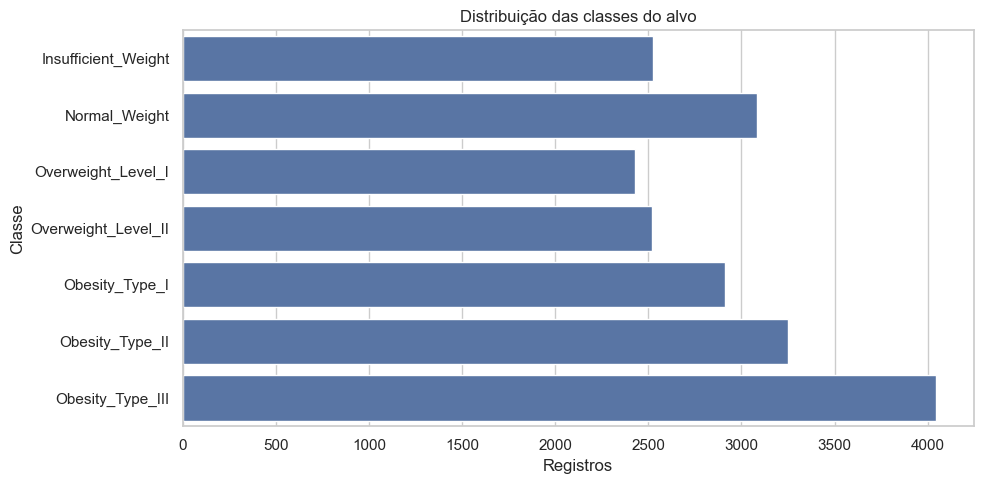

In [7]:
target_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III',
]
target_distribution = (
    df['NObeyesdad']
    .value_counts()
    .reindex(target_order)
    .rename_axis('classe')
    .reset_index(name='registros')
)
target_distribution['percentual'] = (
    target_distribution['registros'] / len(df) * 100
).round(2)
display(target_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=target_distribution, x='registros', y='classe', color='#4C72B0')
plt.title('Distribuição das classes do alvo')
plt.xlabel('Registros')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

## 6. Relação antropométrica e possível circularidade

O IMC abaixo é derivado somente para auditoria. Como o alvo está fortemente relacionado a altura e peso, compare futuramente modelos com e sem essas variáveis para evitar conclusões artificialmente otimistas.

,count,mean,median,min,max
NObeyesdad,,,,,
Insufficient_Weight,2523,17.58,17.51,12.87,36.78
Normal_Weight,3082,22.00,22.04,14.63,32.88
Overweight_Level_I,2427,26.06,25.96,15.76,35.56
Overweight_Level_II,2522,28.19,28.02,21.51,36.74
Obesity_Type_I,2910,32.15,32.12,16.60,46.81
Obesity_Type_II,3248,36.52,36.38,24.05,46.22
Obesity_Type_III,4046,41.78,41.75,18.18,55.00


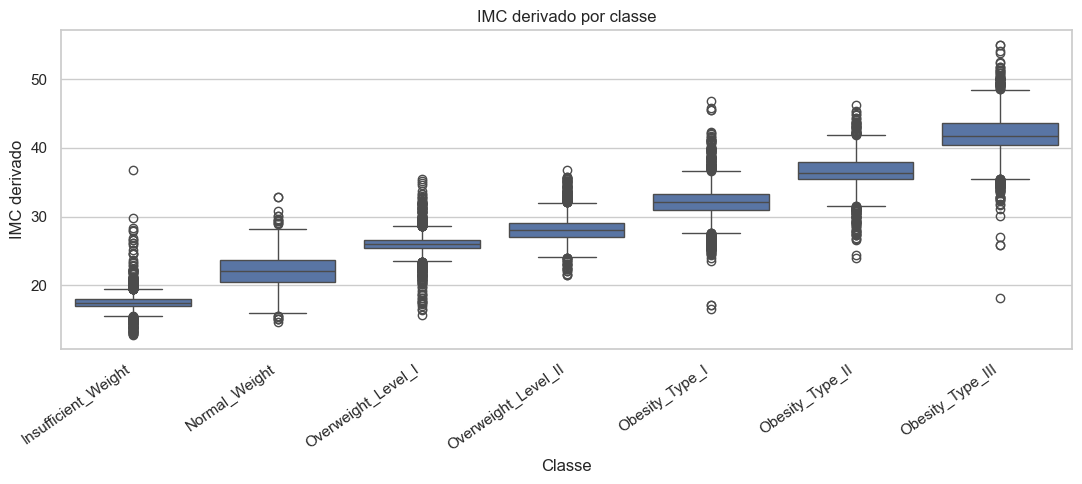

In [8]:
analysis_df = df.assign(BMI=df['Weight'] / df['Height'].pow(2))
bmi_by_target = (
    analysis_df.groupby('NObeyesdad', observed=True)['BMI']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reindex(target_order)
    .round(2)
)
display(bmi_by_target)

plt.figure(figsize=(11, 5))
sns.boxplot(data=analysis_df, x='NObeyesdad', y='BMI', order=target_order)
plt.xticks(rotation=35, ha='right')
plt.title('IMC derivado por classe')
plt.xlabel('Classe')
plt.ylabel('IMC derivado')
plt.tight_layout()
plt.show()

## 7. Auditoria inicial por gênero

Gender,Female,Male
NObeyesdad,,
Insufficient_Weight,64.25,35.75
Normal_Weight,53.86,46.14
Overweight_Level_I,44.09,55.91
Overweight_Level_II,29.94,70.06
Obesity_Type_I,43.54,56.46
Obesity_Type_II,0.25,99.75
Obesity_Type_III,99.88,0.12


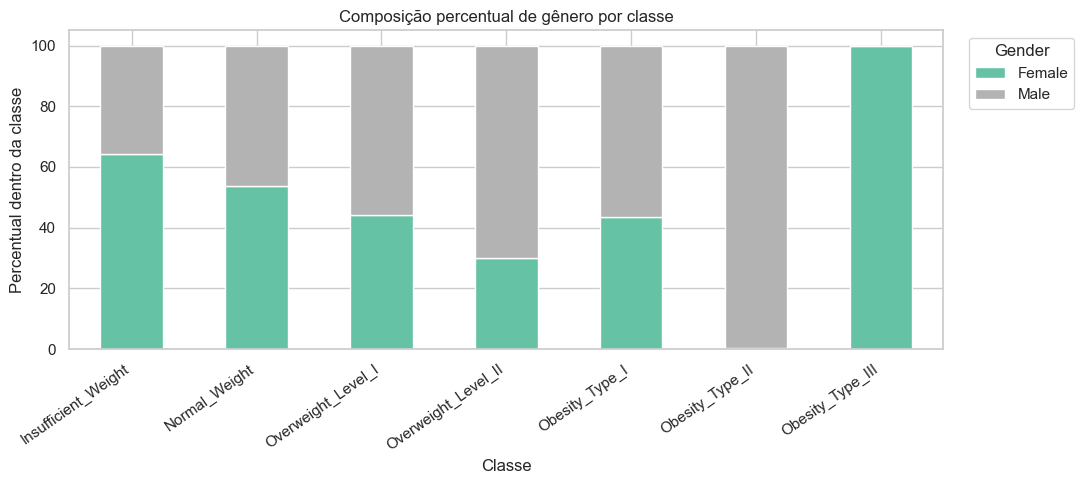

In [9]:
gender_by_target = (
    pd.crosstab(
        df['NObeyesdad'],
        df['Gender'],
        normalize='index',
    )
    .mul(100)
    .reindex(target_order)
    .round(2)
)
display(gender_by_target)

gender_by_target.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='Set2')
plt.title('Composição percentual de gênero por classe')
plt.xlabel('Classe')
plt.ylabel('Percentual dentro da classe')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Próximas análises sugeridas

- Investigar categorias raras em `SMOKE`, `SCC` e `MTRANS`.
- Comparar distribuições numéricas e ordinais entre as sete classes.
- Procurar registros quase duplicados antes do split.
- Auditar a associação quase determinística entre gênero e algumas classes.
- Definir o objetivo real: reproduzir o estado de peso atual ou estimar suscetibilidade sem peso/IMC.
- Manter toda transformação reutilizável em módulos Python com `fit` restrito ao treino; o notebook deve permanecer exploratório.

In [14]:
df['Age'].min(), df['Age'].max()

(np.float64(14.0), np.float64(61.0))

In [17]:
list([df['Age']])

[0        24.443011
 1        18.000000
 2        18.000000
 3        20.952737
 4        31.641081
            ...    
 20753    25.137087
 20754    18.000000
 20755    20.101026
 20756    33.852953
 20757    26.680376
 Name: Age, Length: 20758, dtype: float64]